In [12]:
# Task 3: Model Comparison 
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import hog
import joblib
import time
import pandas as pd
import os
from PIL import Image
from pathlib import Path


In [22]:
DATA_PATH = 'handwritten_dataset'

print(f"Looking for data in: {DATA_PATH}")

def load_data(data_path, img_size=45):
    """Load images from the math symbols dataset"""
    print("Loading dataset...")
    X_data = []
    y_data = []
    
    # Get all class folders (alpha, beta, etc.)
    class_folders = sorted([f for f in os.listdir(data_path) 
                            if os.path.isdir(os.path.join(data_path, f))])
    class_names = class_folders
    
    print(f"Found {len(class_names)} classes")
    print(f"First 10 classes: {class_names[:10]}")
    
    # Load images from each class folder
    for label_idx, class_folder in enumerate(class_folders):
        class_path = os.path.join(data_path, class_folder)
        image_files = [f for f in os.listdir(class_path) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path).convert('L')  # Grayscale
                img = img.resize((img_size, img_size))   # Resize to 45x45
                img_array = np.array(img)
                X_data.append(img_array)
                y_data.append(label_idx)
            except:
                pass  # Skip broken images
        
        # Show progress
        if (label_idx + 1) % 10 == 0:
            print(f"Loaded {label_idx + 1}/{len(class_folders)} classes...")
    
    # Convert to arrays
    X_data = np.array(X_data)
    y_data = np.array(y_data)
    
    print(f"Total images: {len(X_data)}")
    
    # Shuffle
    np.random.seed(42)
    indices = np.random.permutation(len(X_data))
    X_data = X_data[indices]
    y_data = y_data[indices]
    
    # Split 80/20
    split = int(0.8 * len(X_data))
    X_train = X_data[:split]
    y_train = y_data[:split]
    X_test = X_data[split:]
    y_test = y_data[split:]
    
    return X_train, y_train, X_test, y_test, class_names

# Load the dataset
X_train, y_train, X_test, y_test, class_names = load_data(DATA_PATH)
NUM_CLASSES = len(class_names)

# Normalize to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN (add channel dimension)
X_train_cnn = X_train.reshape(-1, 45, 45, 1)
X_test_cnn = X_test.reshape(-1, 45, 45, 1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print("\n" + "="*50)
print("✓ DATASET LOADED!")
print("="*50)
print(f"Classes: {NUM_CLASSES}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print("="*50)

Looking for data in: handwritten_dataset
Loading dataset...
Found 19 classes
First 10 classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Loaded 10/19 classes...
Total images: 10071

✓ DATASET LOADED!
Classes: 19
Training samples: 8056
Test samples: 2015


In [23]:
# CNN Model (Deep Learning)
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN model using the new Input layer (preferred style)
cnn = Sequential([
    Input(shape=(45, 45, 1)),  # Changed to 45x45 for new dataset
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax') 
])

# Compile model
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
import time
start = time.time()
history = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=128, validation_split=0.1, verbose=1)
cnn_time = time.time() - start

# Evaluate on test data
cnn_eval = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
cnn_acc = cnn_eval[1]

# Save model 
cnn.save("cnn_model.keras")

print(f"CNN Test Accuracy: {cnn_acc*100:.2f}% | Training time: {cnn_time:.1f}s")


Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.2164 - loss: 2.5783 - val_accuracy: 0.5347 - val_loss: 1.6555
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5484 - loss: 1.4831 - val_accuracy: 0.7494 - val_loss: 0.9068
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6957 - loss: 0.9913 - val_accuracy: 0.8164 - val_loss: 0.6724
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7623 - loss: 0.7731 - val_accuracy: 0.8325 - val_loss: 0.5413
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8103 - loss: 0.6217 - val_accuracy: 0.8846 - val_loss: 0.4324
CNN Test Accuracy: 86.50% | Training time: 15.1s


In [24]:
# Use a smaller training subset to speed up SVM training
X_train_small = X_train[:20000]
y_train_small = y_train[:20000]

# Extract HOG (Histogram of Oriented Gradients) features from images
def extract_hog_features(images):
    return np.array([
        hog(img, pixels_per_cell=(4,4), cells_per_block=(2,2), visualize=False)
        for img in images
    ])

print("Extracting HOG features (this may take a while)...")
X_train_hog = extract_hog_features(X_train_small)
X_test_hog = extract_hog_features(X_test)

# Create and train SVM classifier
svm_clf = svm.SVC(kernel='linear')

start = time.time()
svm_clf.fit(X_train_hog, y_train_small)
svm_time = time.time() - start

# Test the SVM model
y_pred_svm = svm_clf.predict(X_test_hog)
svm_acc = accuracy_score(y_test, y_pred_svm)

# Save model
joblib.dump(svm_clf, "svm_hog.pkl")

print(f"SVM + HOG Accuracy: {svm_acc*100:.2f}% | Training time: {svm_time:.1f}s")


Extracting HOG features (this may take a while)...
SVM + HOG Accuracy: 87.34% | Training time: 22.6s


In [25]:
# Create k-Nearest Neighbors model with k=3
knn = KNeighborsClassifier(n_neighbors=3)

start = time.time()
knn.fit(X_train_hog, y_train_small)
knn_time = time.time() - start

# Evaluate kNN
y_pred_knn = knn.predict(X_test_hog)
knn_acc = accuracy_score(y_test, y_pred_knn)

# Save model
joblib.dump(knn, "knn.pkl")

print(f"k-NN Accuracy: {knn_acc*100:.2f}% | Training time: {knn_time:.1f}s")


k-NN Accuracy: 73.45% | Training time: 0.0s


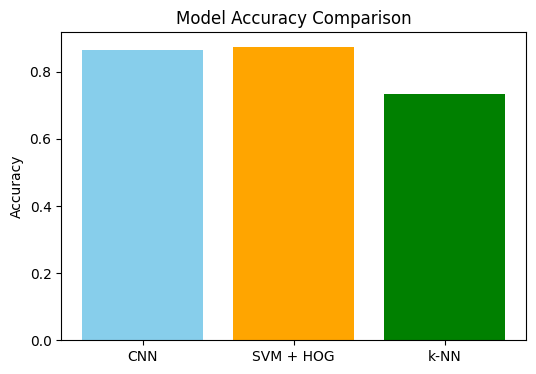

CNN         Accuracy: 86.50%   |   Training time: 15.1s
SVM + HOG   Accuracy: 87.34%   |   Training time: 22.6s
k-NN        Accuracy: 73.45%   |   Training time: 0.0s


In [26]:
# Collect model performance metrics
models = ['CNN', 'SVM + HOG', 'k-NN']
accs = [cnn_acc, svm_acc, knn_acc]
times = [cnn_time, svm_time, knn_time]

# Plot bar chart for visual comparison
# Remove the plt.ylim() line entirely
plt.figure(figsize=(6,4))
plt.bar(models, accs, color=['skyblue','orange','green'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Display formatted summary
for m,a,t in zip(models,accs,times):
    print(f"{m:10s}  Accuracy: {a*100:.2f}%   |   Training time: {t:.1f}s")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


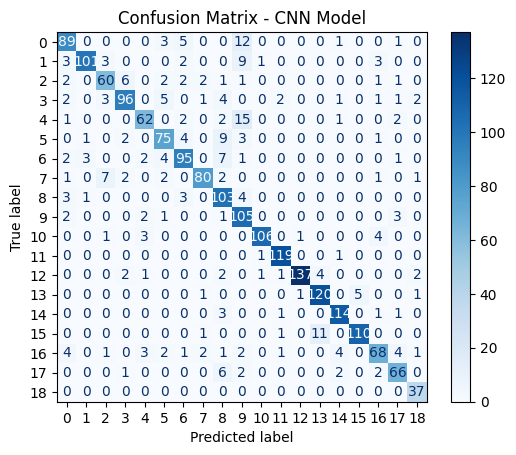

In [27]:
# Generate predictions for the test set
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_cnn)

# Display confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - CNN Model")
plt.show()


In [28]:
# Combine model performance into a summary DataFrame
summary = {
    'Model': ['CNN', 'SVM + HOG', 'k-NN'],
    'Accuracy (%)': [cnn_acc*100, svm_acc*100, knn_acc*100],
    'Training Time (s)': [cnn_time, svm_time, knn_time]
}

df = pd.DataFrame(summary)
print("Final Comparison Table:")
display(df)


Final Comparison Table:


,Model,Accuracy (%),Training Time (s)
0,CNN,86.501241,15.055598
1,SVM + HOG,87.344913,22.582650
2,k-NN,73.449132,0.013845
